In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

In [2]:
# SPY500 historical data
data = pd.read_csv("../data/SP500.csv")
data.head(), data.shape

(         Date      Close       High        Low       Open  Volume
 0  12/30/1927  17.660000  17.660000  17.660000  17.660000       0
 1    1/3/1928  17.760000  17.760000  17.760000  17.760000       0
 2    1/4/1928  17.719999  17.719999  17.719999  17.719999       0
 3    1/5/1928  17.549999  17.549999  17.549999  17.549999       0
 4    1/6/1928  17.660000  17.660000  17.660000  17.660000       0,
 (24532, 6))

In [3]:
data['Date'] = pd.to_datetime(data['Date'])
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 24532 entries, 0 to 24531
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    24532 non-null  datetime64[us]
 1   Close   24532 non-null  float64       
 2   High    24532 non-null  float64       
 3   Low     24532 non-null  float64       
 4   Open    24532 non-null  float64       
 5   Volume  24532 non-null  int64         
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 1.1 MB


In [5]:
# Filter the data from 2022 to latest available
def filter_data(df: pd.DataFrame, start_date: str, end_date: str):
    mask = (df['Date'] >= start_date) & (df['Date'] <= end_date)

    return df.loc[mask]

data = filter_data(data, start_date="2022-01-01", end_date="2025-12-31")
data.reset_index(inplace=True, drop=True)

In [6]:
data

,Date,Close,High,Low,Open,Volume
0,2022-01-03,4796.560059,4796.640137,4758.169922,4778.140137,3831020000
1,2022-01-04,4793.540039,4818.620117,4774.270020,4804.509766,4683170000
2,2022-01-05,4700.580078,4797.700195,4699.439941,4787.990234,4887960000
3,2022-01-06,4696.049805,4725.009766,4671.259766,4693.390137,4295280000
4,2022-01-07,4677.029785,4707.950195,4662.740234,4697.660156,4181510000
...,...,...,...,...,...,...
913,2025-08-25,6439.319824,6466.890137,6438.060059,6457.669922,4059070000
914,2025-08-26,6465.939941,6468.370117,6429.209961,6435.490234,4867680000
915,2025-08-27,6481.399902,6487.060059,6457.839844,6462.259766,4143680000
916,2025-08-28,6501.859863,6508.229980,6466.959961,6483.839844,4283760000


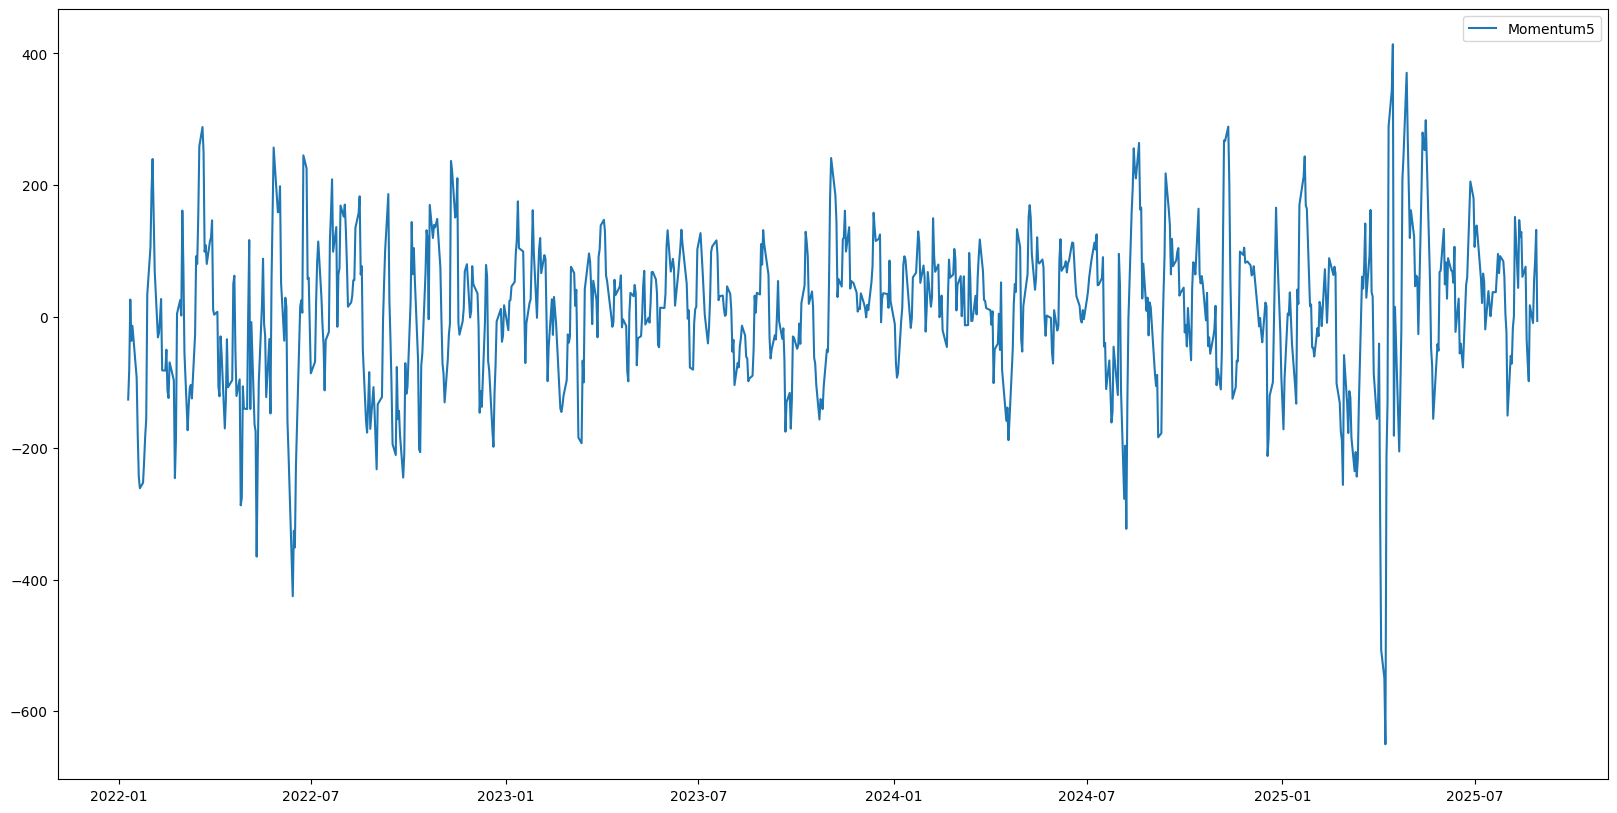

In [ ]:
# Plot the 5-day momentum and 5-day moving average

data['momentum_5'] = data['Close'] - data['Close'].shift(5)

plt.rcParams["figure.figsize"] = (20, 10)
plt.plot(data['Date'], data['momentum_5'] , label='Momentum5')
plt.legend()

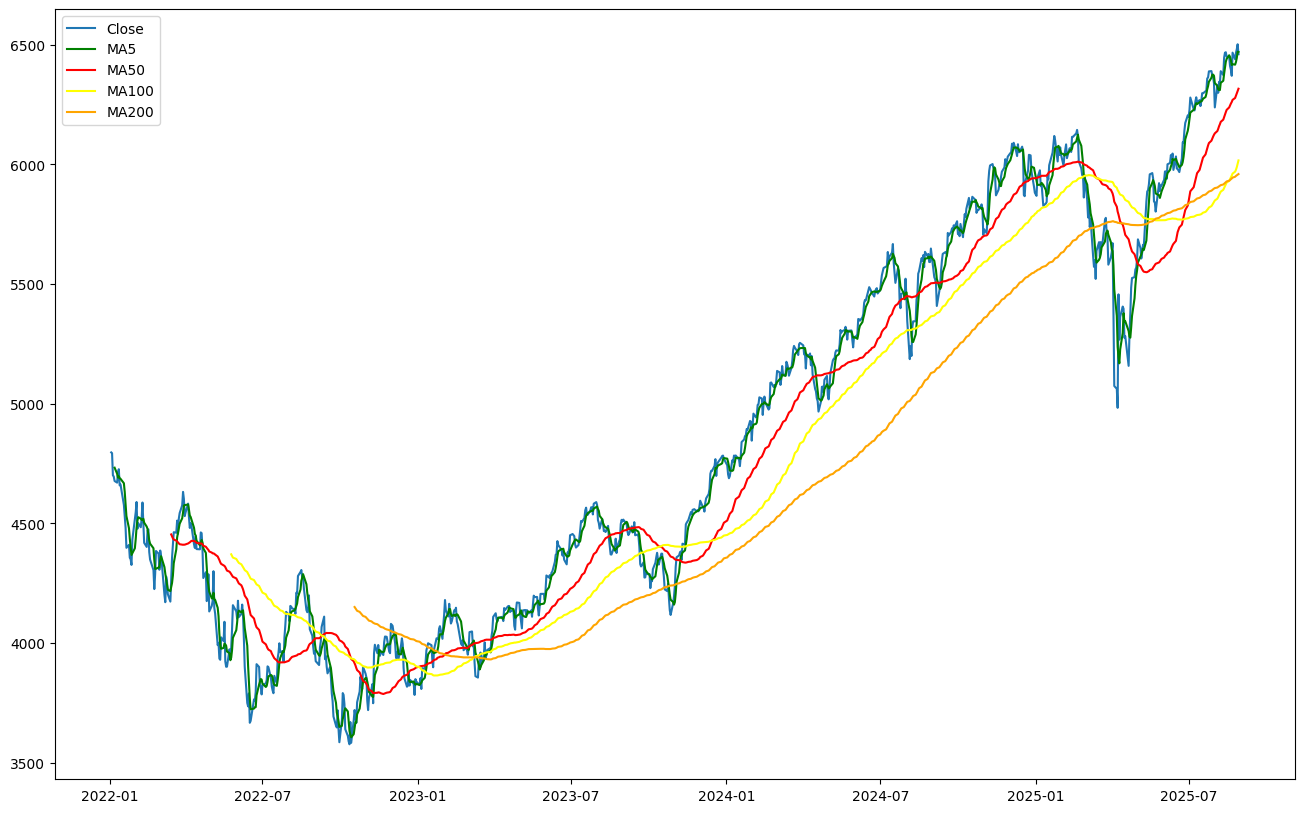

In [ ]:
data['moving_avg_5'] = data['Close'].rolling(window=5).mean()

plt.rcParams["figure.figsize"] = (16,10)
plt.plot(data['Date'], data['Close'], label='Close')
plt.plot(data['Date'], data['moving_avg_5'], c='green', label='MA5')
plt.plot(data['Date'], data['Close'].rolling(window=50).mean(), c='red', label='MA50')
plt.plot(data['Date'], data['Close'].rolling(window=100).mean(), c='yellow', label='MA100')
plt.plot(data['Date'], data['Close'].rolling(window=200).mean(), c='orange', label='MA200')
plt.legend()

In [9]:
data['Close'].rolling(window=5).mean()

0              NaN
1              NaN
2              NaN
3              NaN
4      4732.751953
          ...     
913    6416.709961
914    6427.623926
915    6444.747949
916    6471.085937
917    6469.755859
Name: Close, Length: 918, dtype: float64

In [26]:
data

,Date,Close,High,Low,Open,Volume,momentum_5,moving_avg_5
0,2022-01-03,4796.560059,4796.640137,4758.169922,4778.140137,3831020000,NaN,NaN
1,2022-01-04,4793.540039,4818.620117,4774.270020,4804.509766,4683170000,NaN,NaN
2,2022-01-05,4700.580078,4797.700195,4699.439941,4787.990234,4887960000,NaN,NaN
3,2022-01-06,4696.049805,4725.009766,4671.259766,4693.390137,4295280000,NaN,NaN
4,2022-01-07,4677.029785,4707.950195,4662.740234,4697.660156,4181510000,NaN,4732.751953
...,...,...,...,...,...,...,...,...
913,2025-08-25,6439.319824,6466.890137,6438.060059,6457.669922,4059070000,-9.830078,6416.709961
914,2025-08-26,6465.939941,6468.370117,6429.209961,6435.490234,4867680000,54.569824,6427.623926
915,2025-08-27,6481.399902,6487.060059,6457.839844,6462.259766,4143680000,85.620117,6444.747949
916,2025-08-28,6501.859863,6508.229980,6466.959961,6483.839844,4283760000,131.689941,6471.085937
